In [2]:
# coding: utf-8
# наше всё
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams

# настройки pandas, с которыми лучше почти всегда
pd.set_option('display.max_rows', 45000)
pd.set_option('display.max_columns', 50000)
pd.set_option('display.max_colwidth', 5000)

# графики в svg выглядят более четкими
%config InlineBackend.figure_format = 'svg' 
rcParams['figure.figsize'] = 16, 12

In [3]:
source_df = pd.read_excel('qval1.xlsx', sheet_name='Worksheet')

In [4]:
res_df = source_df.copy()
diff_df = res_df.copy()
for i in range(1, len(diff_df.columns)-2):
    diff_df[i] = np.sum(diff_df[i]) / len(diff_df[i])



pot_df = res_df.copy()
for i in range(1, len(diff_df.columns)-2):
    pot_df[i] = diff_df[i] * res_df[i]


diff_df = diff_df[0:1][diff_df.columns[3:]].T
diff_df = diff_df.reset_index()
diff_df.columns = ['question', 'difficulty']


In [5]:
diff_df.sample(3)

,question,difficulty
6,7,0.250
27,28,0.375
31,32,0.250


In [6]:
diff_df.sort_values(by='difficulty', ascending=False)[0:3]

,question,difficulty
7,8,0.7500
23,24,0.6875
5,6,0.6875


In [7]:
diff_df.sort_values(by='difficulty', ascending=True)[0:3]

,question,difficulty
22,23,0.0000
3,4,0.0625
19,20,0.0625


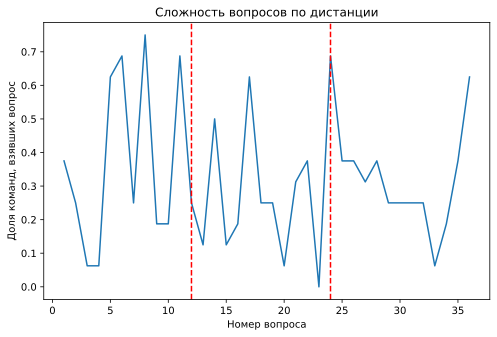

In [8]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=diff_df, x='question', y='difficulty')
plt.xlabel('Номер вопроса')
plt.ylabel('Доля команд, взявших вопрос')
plt.title('Сложность вопросов по дистанции')
#  вертикальная линия при x = 12 и x = 24
plt.axvline(x=12, color='red', linestyle='--')
plt.axvline(x=24, color='red', linestyle='--')
plt.show()


<Figure size 800x500 with 0 Axes>

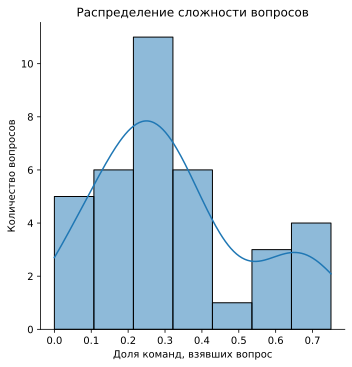

In [9]:
plt.figure(figsize=(8, 5))
sns.displot(diff_df['difficulty'], kde=True)
plt.xlabel('Доля команд, взявших вопрос')
plt.ylabel('Количество вопросов')
plt.title('Распределение сложности вопросов')
plt.show()






In [10]:
team_stat = res_df[res_df.columns[0:3]].copy()
team_stat['result'] = np.sum(res_df[res_df.columns[3:]], axis=1)
team_stat['difficulty'] = np.sum(pot_df[pot_df.columns[3:]], axis=1)
team_stat['potential'] = team_stat['difficulty'] / team_stat['result']


In [11]:
team_stat

,Team ID,Название,Город,result,difficulty,potential
0,54256,Квасной либерализм,Москва,22,8.5625,0.389205
1,92088,полсу4ка,Москва,13,6.7500,0.519231
2,107732,Пошлые моли,Москва,15,6.3125,0.420833
3,107733,Бегущие к Житенёву,Москва,12,4.5625,0.380208
4,98892,Просто написал и сразу напился,Москва,12,6.1875,0.515625
5,92053,"Лишайниковая, 10",Москва,12,5.2500,0.437500
6,93365,Киви,Москва,11,5.4375,0.494318
7,107735,Да Да ОКДФ,Москва,9,4.8750,0.541667
8,92034,Орлеанские девы,Москва,5,2.4375,0.487500
9,104740,Ирис Кис-Кис,Москва,15,6.8750,0.458333


In [12]:
team_stat[['result']].describe()

,result
count,16.000000
mean,11.562500
std,6.098839
min,3.000000
25%,7.750000
50%,11.500000
75%,13.500000
max,26.000000


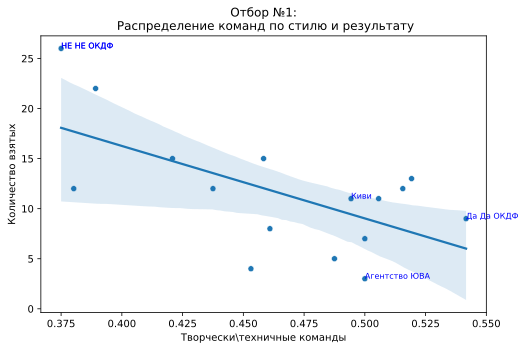

In [13]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=team_stat, 
    x="potential", 
    y="result",
    )

plt.title("Отбор №1:\n Распределение команд по стилю и результату")
# add a trend line
sns.regplot(data=team_stat, x="potential", y="result", scatter=False)

# add points
x1 = np.min(team_stat['potential'])
y1 = team_stat[team_stat['potential'] == x1]['result'].values[0]
name1 = team_stat[team_stat['potential'] == x1]['Название'].values[0]
plt.text(x1, y1, name1, fontsize=8, color='blue')

x2 = np.max(team_stat['potential'])
y2 = team_stat[team_stat['potential'] == x2]['result'].values[0]
name2 = team_stat[team_stat['potential'] == x2]['Название'].values[0]
plt.text(x2, y2, name2, fontsize=8, color='blue')

y3 = np.max(team_stat['result'])
x3 = team_stat[team_stat['result'] == y3]['potential'].values[0]
name3 = team_stat[team_stat['result'] == y3]['Название'].values[0]
plt.text(x3, y3, name3, fontsize=8, color='blue')

y4 = np.min(team_stat['result'])
x4 = team_stat[team_stat['result'] == y4]['potential'].values[0]
name4 = team_stat[team_stat['result'] == y4]['Название'].values[0]
plt.text(x4, y4, name4, fontsize=8, color='blue')

x5 = team_stat['potential'].values[np.random.randint(0, len(team_stat))]
y5 = team_stat[team_stat['potential'] == x5]['result'].values[0]
name5 = team_stat[team_stat['potential'] == x5]['Название'].values[0]
plt.text(x5, y5, name5, fontsize=8, color='blue')

plt.xlabel("Творчески\техничные команды")
plt.ylabel("Количество взятых")

plt.show()






In [14]:
# сильные техничные команды
team_stat[
    (team_stat['potential'] > np.mean(team_stat['potential'])) & 
    (team_stat['result'] > np.mean(team_stat['result']))
]['Название']

1                          полсу4ка
4    Просто написал и сразу напился
Name: Название, dtype: object

In [15]:
# сильные творческие команды
team_stat[
    (team_stat['potential'] < np.mean(team_stat['potential'])) & 
    (team_stat['result'] > np.mean(team_stat['result']))
]['Название']

0     Квасной либерализм
2            Пошлые моли
3     Бегущие к Житенёву
5       Лишайниковая, 10
9           Ирис Кис-Кис
15            НЕ НЕ ОКДФ
Name: Название, dtype: object

In [16]:
team_stat.sort_values(by='potential', ascending=True)[0:5]

,Team ID,Название,Город,result,difficulty,potential
15,107738,НЕ НЕ ОКДФ,Москва,26,9.7500,0.375000
3,107733,Бегущие к Житенёву,Москва,12,4.5625,0.380208
0,54256,Квасной либерализм,Москва,22,8.5625,0.389205
2,107732,Пошлые моли,Москва,15,6.3125,0.420833
5,92053,"Лишайниковая, 10",Москва,12,5.2500,0.437500


In [17]:
team_stat.sort_values(by='potential', ascending=False)[0:5]

,Team ID,Название,Город,result,difficulty,potential
7,107735,Да Да ОКДФ,Москва,9,4.8750,0.541667
1,92088,полсу4ка,Москва,13,6.7500,0.519231
4,98892,Просто написал и сразу напился,Москва,12,6.1875,0.515625
11,107736,Смех не грех,Москва,11,5.5625,0.505682
10,104470,Агентство ЮВА,Москва,3,1.5000,0.500000


In [18]:
team_qv_df = res_df.melt(
    id_vars=['Название', 'Город', 'Team ID'],
    value_vars=res_df.columns[3:],
    var_name='question',
    value_name='qv_result'
)
team_qv_df = team_qv_df.merge(
    diff_df, 
    'left',
    on='question'
)
team_qv_df = team_qv_df.merge(
    team_stat,
    'left',
    on=['Название', 'Team ID', 'Город'],
    suffixes=('_qv', '_total')
)
team_qv_df['epic'] = team_qv_df['result'] * team_qv_df['difficulty_qv']




In [19]:
# топ эпических взятий
team_qv_df[team_qv_df['qv_result'] == 1].sort_values(by='epic', ascending=True)[0:3]

,Название,Город,Team ID,question,qv_result,difficulty_qv,result,difficulty_total,potential,epic
317,Тамбовский волк,Москва,107544,20,1,0.0625,4,1.8125,0.453125,0.2500
538,Агентство ЮВА,Москва,104470,34,1,0.1875,3,1.5000,0.500000,0.5625
38,Киви,Москва,93365,3,1,0.0625,11,5.4375,0.494318,0.6875


In [20]:
# топ эпических продолбов
team_qv_df[team_qv_df['qv_result'] == 0].sort_values(by='epic', ascending=False)[0:4]

,Название,Город,Team ID,question,qv_result,difficulty_qv,result,difficulty_total,potential,epic
208,Квасной либерализм,Москва,54256,14,0,0.5000,22,8.5625,0.389205,11.0000
162,Пошлые моли,Москва,107732,11,0,0.6875,15,6.3125,0.420833,10.3125
370,Пошлые моли,Москва,107732,24,0,0.6875,15,6.3125,0.420833,10.3125
89,Ирис Кис-Кис,Москва,104740,6,0,0.6875,15,6.8750,0.458333,10.3125


In [21]:
res_df = res_df.merge(
    team_stat,
    'left',
    on=['Название', 'Team ID', 'Город'],
    suffixes=('_qv', '_total')
)
res_df.sample(3)


,Team ID,Название,Город,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,result,difficulty,potential
3,107733,Бегущие к Житенёву,Москва,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,0,0,1,1,1,0,0,0,1,0,0,1,1,0,12,4.5625,0.380208
7,107735,Да Да ОКДФ,Москва,0,0,0,0,1,1,0,1,0,0,0,0,1,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,9,4.8750,0.541667
8,92034,Орлеанские девы,Москва,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,5,2.4375,0.487500


In [22]:
# корреляция между столбцам в data frame
correlations_with_result = pd.DataFrame(res_df[res_df.columns[3:-2]].corr()['result'])
correlations_with_result.columns = ['correlation']
correlations_with_result.sort_values(by='correlation', ascending=False)[0:7]

,correlation
result,1.000000
15,0.796070
9,0.767738
12,0.727166
10,0.713505
2,0.702723
22,0.669526


In [23]:
correlations_with_result.sort_values(by='correlation', ascending=True)[0:5]

,correlation
20,-0.330664
34,-0.208459
3,-0.024595
35,0.013664
4,0.019129


In [24]:
res_df.sample(3)

,Team ID,Название,Город,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,result,difficulty,potential
10,104470,Агентство ЮВА,Москва,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,3,1.5000,0.500000
3,107733,Бегущие к Житенёву,Москва,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,0,0,1,1,1,0,0,0,1,0,0,1,1,0,12,4.5625,0.380208
5,92053,"Лишайниковая, 10",Москва,1,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,1,1,1,12,5.2500,0.437500


In [25]:
top_3 = list(correlations_with_result.sort_values(by='correlation', ascending=False)[1:4].index)
top_5 = list(correlations_with_result.sort_values(by='correlation', ascending=False)[1:6].index)

In [26]:
res_df['top-3'] = np.sum(res_df[res_df.columns[res_df.columns.isin(top_3)]], axis=1)
res_df['top-5'] = np.sum(res_df[res_df.columns[res_df.columns.isin(top_5)]], axis=1)
res_df.sample(3)






,Team ID,Название,Город,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,result,difficulty,potential,top-3,top-5
15,107738,НЕ НЕ ОКДФ,Москва,1,1,0,0,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,0,1,1,0,1,1,0,1,1,1,1,0,0,1,0,0,1,26,9.7500,0.375000,3,5
2,107732,Пошлые моли,Москва,0,1,0,0,1,1,0,1,0,0,0,0,0,0,0,1,1,0,1,0,1,0,0,0,1,1,0,1,0,1,0,1,0,0,1,1,15,6.3125,0.420833,0,1
1,92088,полсу4ка,Москва,0,0,0,0,1,1,0,1,0,1,1,1,0,1,0,0,1,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,1,1,13,6.7500,0.519231,1,2


In [27]:
res_df[['top-3', 'top-5', 'result']].corr()

,top-3,top-5,result
top-3,1.000000,0.961073,0.829043
top-5,0.961073,1.000000,0.880765
result,0.829043,0.880765,1.000000


In [31]:
team_qv_df[team_qv_df['Название'] == 'Да Да ОКДФ'].sort_values(by='epic', ascending=False)

,Название,Город,Team ID,question,qv_result,difficulty_qv,result,difficulty_total,potential,epic
119,Да Да ОКДФ,Москва,107735,8,1,0.7500,9,4.875,0.541667,6.7500
375,Да Да ОКДФ,Москва,107735,24,1,0.6875,9,4.875,0.541667,6.1875
87,Да Да ОКДФ,Москва,107735,6,1,0.6875,9,4.875,0.541667,6.1875
167,Да Да ОКДФ,Москва,107735,11,0,0.6875,9,4.875,0.541667,6.1875
263,Да Да ОКДФ,Москва,107735,17,1,0.6250,9,4.875,0.541667,5.6250
71,Да Да ОКДФ,Москва,107735,5,1,0.6250,9,4.875,0.541667,5.6250
567,Да Да ОКДФ,Москва,107735,36,1,0.6250,9,4.875,0.541667,5.6250
215,Да Да ОКДФ,Москва,107735,14,1,0.5000,9,4.875,0.541667,4.5000
343,Да Да ОКДФ,Москва,107735,22,0,0.3750,9,4.875,0.541667,3.3750
551,Да Да ОКДФ,Москва,107735,35,0,0.3750,9,4.875,0.541667,3.3750
